[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/06_ai_engineering/23_embeddings_retrieval.ipynb)

# 📓 Notebook 23 — Embeddings and Semantic Retrieval

> **Module:** AI Engineering · **Estimated time:** 60–80 min · **Difficulty:** Intermediate

In Notebook 22 we built a tiny RAG (retrieval-augmented generation) pipeline using **keyword overlap**. That worked for an introduction, but it has a glaring weakness: a customer asking *"how do I end my plan?"* won't match a document about *"cancelling your subscription"* because the words don't overlap.

This notebook fixes that. We build a **semantic** retriever — one that compares meaning, not strings — using two complementary approaches:

1. **TF-IDF + cosine similarity** — works offline, no model download, surprisingly strong baseline.
2. **Dense embeddings** (e.g. `sentence-transformers` or OpenAI's embedding API) — the modern default.

We then run a **head-to-head evaluation** of all three retrievers (keyword, TF-IDF, dense) on the same test set, and learn which wins on which kind of question. By the end you will have built every piece of a production-grade RAG system except the vector database — and the vector database, as you'll see, is just a faster version of the dictionary we'll write by hand.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Explain what an **embedding** is and what **cosine similarity** measures.
2. Build a **TF-IDF retriever** with scikit-learn (offline, no API calls).
3. Build an embedding-based retriever using a hosted API or a local model (with a deterministic offline fallback).
4. Compute **retrieval@k** and **MRR** to evaluate retrievers.
5. Compare keyword vs TF-IDF vs dense retrieval on the same test set.
6. Combine retrieval with an LLM to answer questions about your own documents.
7. Recognise the failure modes (synonyms, paraphrase, domain jargon) and pick the right retriever.

## ✅ Prerequisites

Notebook 22 (the keyword-RAG version) — you'll see the same pattern, upgraded.
NB 5 (functions), NB 8 (NumPy), NB 14 (sklearn).

## 1. What is an embedding?

An **embedding** turns a piece of text into a fixed-length vector of numbers such that **similar meanings end up close in space**.

```
"How do I cancel my subscription?"      →  [0.12, -0.45, 0.78, ..., 0.03]  (300 numbers)
"What's the process to end my plan?"    →  [0.10, -0.43, 0.81, ..., 0.05]  (close!)
"How is the weather in Tokyo?"          →  [0.66,  0.21, -0.10, ..., 0.55] (far!)
```

The numbers themselves are not meaningful to humans. What matters is the **distance** between vectors: similar texts produce vectors with high **cosine similarity** (close to 1), unrelated texts produce vectors close to 0.

> 🎯 **Why this beats keyword matching.** Two sentences that share meaning but no words ("end my plan" vs "cancel my subscription") will have nearby vectors. Keyword matching cares only about literal word overlap and misses everything that needs paraphrasing.

### 🔬 What actually happens — "find similar text" is just geometry

The two-line story above ("text → vector → close vectors mean close meanings") hides the one mechanism that makes *all* of retrieval work. Let's pull it apart until there is no magic left. There are exactly **three moves**:

```text
        text                       embedding (a vector)
   "cancel my plan"   ──embed──▶   [ 0.9,  0.1 ]
   "end subscription" ──embed──▶   [ 0.8,  0.2 ]      ← points the SAME way  → similar
   "weather in Tokyo" ──embed──▶   [-0.3,  0.9 ]      ← points a DIFFERENT way → unrelated
```

**Move 1 — embed.** A function turns each text into a fixed-length list of numbers (a *vector*). Same length for every text — 2 here, 256 for our `MockEmbedder` below, 1536 for OpenAI. The numbers are coordinates of a *point in space*.

**Move 2 — measure the angle, not the distance.** Two texts are "similar" when their vectors **point in the same direction**. We measure direction-agreement with **cosine similarity** — the cosine of the angle between the two arrows:

```text
        ▲ dim 2
        │        b = [0.8, 0.2]
        │      ↗  a = [0.9, 0.1]   small angle θ  →  cos θ ≈ 1  (very similar)
        │    ↗↗
        │  ↗↗ ) θ
        └─────────────▶ dim 1

   cos 0°  = 1.0   same direction   → identical meaning
   cos 90° = 0.0   perpendicular    → unrelated
   cos 180°= -1.0  opposite         → opposite meaning
```

**Move 3 — rank.** To retrieve, embed the *query*, compute its cosine similarity against every stored vector, sort descending, and take the top-k. That's it. The whole "semantic search" stack is: *embed once, then for each query do a sort by angle.*

> 🧠 **Mental model.** Embeddings turn **meaning into geometry**. Retrieval is just asking: *"which stored arrow points most the same way as my query arrow?"* — nearest neighbours by angle.


### The cosine-similarity formula — what `a @ b / (‖a‖‖b‖)` really computes

Cosine similarity has a one-line formula. For two vectors **a** and **b**:

```text
                 a · b              (dot product: multiply pairwise, then sum)
 cos(a, b) = ───────────────
              ‖a‖ · ‖b‖            (each ‖·‖ is the length: sqrt of sum of squares)
```

Read it in three pieces:

| Piece | NumPy | What it is |
|---|---|---|
| `a · b` (dot product) | `a @ b` | how much the two arrows *overlap* — big when they point alike |
| `‖a‖` (norm / length) | `np.linalg.norm(a)` | the length of arrow `a` (so longer texts don't score higher just for being long) |
| divide by `‖a‖·‖b‖` | — | **rescales to ignore length** — leaves *only the angle* |

That division is the whole trick: it strips out *magnitude* and keeps *direction*. Two vectors pointing the same way score `1.0` whether one is twice as long as the other.

> 💡 **Why normalising first is a shortcut.** If you pre-scale every vector to length 1 (an "L2-normalised" or *unit* vector), then `‖a‖ = ‖b‖ = 1`, and the formula collapses to just `a @ b` — a plain dot product. That is exactly why our `MockEmbedder` (and most real embedding APIs) return unit vectors: cosine similarity becomes a single fast matrix multiply, no division per query.


In [ ]:
# 🧪 PROOF (fully offline) — cosine similarity by hand on tiny 2-D "embeddings".
# We hand-make four toy vectors so you can SEE the geometry. No model, no API.
import numpy as np

# Pretend an embedder gave us these 2-D vectors (one arrow per phrase):
vecs = {
    "cancel my plan":    np.array([0.9, 0.1]),   # \
    "end subscription":  np.array([0.8, 0.2]),   #  } point right-ish  → about money/account
    "refund my money":   np.array([0.7, 0.3]),   # /
    "weather in Tokyo":  np.array([-0.3, 0.9]),  # points up-left      → unrelated
}

def cosine(a, b):
    # The formula, written out exactly: (a · b) / (‖a‖ · ‖b‖)
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Sanity checks first — the three anchor values from the diagram:
print("cos(v, itself)      =", round(cosine(vecs["cancel my plan"],
                                            vecs["cancel my plan"]), 3))   # 1.0  same direction
print("cos(right, up-left) =", round(cosine(np.array([1, 0]),
                                            np.array([0, 1])), 3))         # 0.0  perpendicular
print("cos(right, left)    =", round(cosine(np.array([1, 0]),
                                            np.array([-1, 0])), 3))        # -1.0 opposite


In [ ]:
# 🎯 RETRIEVAL by hand — embed a query, rank every stored vector by cosine, take top-k.
query = "stop my subscription"
q_vec = np.array([0.85, 0.15])          # pretend the embedder placed the query HERE

# Score the query against every stored phrase, then sort high→low:
scored = sorted(
    ((name, cosine(q_vec, v)) for name, v in vecs.items()),
    key=lambda pair: -pair[1],
)

print(f"Query: {query!r}  →  vector {q_vec.tolist()}\n")
print("rank  cosine   phrase")
for rank, (name, sim) in enumerate(scored, start=1):
    bar = "█" * int(sim * 20) if sim > 0 else ""
    print(f"  {rank}   {sim:+.3f}  {name:<18} {bar}")

print(f"\nNearest neighbour (top-1): {scored[0][0]!r}")
# "stop my subscription" lands nearest "cancel my plan" / "end subscription" —
# the account/billing arrows — and FARTHEST from "weather in Tokyo". Meaning → geometry.


In [ ]:
# ✅ VERIFY our by-hand numbers against sklearn's cosine_similarity (optional check).
# sklearn is already a course dependency; this proves our one-liner is the real thing.
from sklearn.metrics.pairwise import cosine_similarity

M = np.array(list(vecs.values()))        # stack the 4 stored vectors into a matrix (4 x 2)
q = np.array([[0.85, 0.15]])             # the query as a 1 x 2 row

sk = cosine_similarity(q, M)[0]          # sklearn computes all four at once
ours = np.array([cosine(q[0], v) for v in M])

print("phrase                sklearn   ours")
for name, s, o in zip(vecs.keys(), sk, ours):
    print(f"  {name:<18} {s:+.4f}  {o:+.4f}")

assert np.allclose(sk, ours), "mismatch!"
print("\n✅ Match — our hand-written a@b/(‖a‖‖b‖) IS cosine similarity.")


### From toy arrows to the real notebook

Everything below in this notebook is the **same three moves at a bigger scale**:

- The 2-D toy vectors become 256-D vectors from `MockEmbedder` (Section 5) — or 1536-D from a real API.
- Our `cosine(a, b)` by-hand loop becomes one matrix multiply, `doc_emb @ q_vec`, because those vectors are already unit-length (so cosine = dot product — the shortcut from two cells up).
- "take the top-1" becomes `np.argsort(-sims)[:k]` to grab the top-k nearest neighbours.

> ⚠️ **The one thing that's genuinely hard is the embedder, not the search.** Ranking by cosine is trivial arithmetic you just did by hand. *Producing vectors where "end my plan" lands near "cancel subscription"* is what a 100M-parameter neural network is trained to do — and why our deterministic mock will sometimes miss what a real `sentence-transformers` model nails. The retrieval code never changes; only the quality of the arrows does.

> 🧠 **Carry this forward.** Whenever you see "vector search", "semantic search", or "a vector database", picture the tiny ranked list you just printed. A vector DB (Pinecone, Qdrant, FAISS) is *only* a faster, indexed version of that `sort by cosine` — built so you don't compare against millions of vectors one at a time.


## 2. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

# The mini knowledge base from NB 17 — same docs (plus a few new ones), so we can compare fairly
DOCS = [
    ("billing.refunds",
     "Refunds are issued within 5 business days. Customers can request a "
     "refund from the Billing page if the request is within 30 days of purchase."),
    ("billing.subscriptions",
     "Subscriptions renew automatically. To cancel, go to Settings → Billing "
     "and click 'Cancel subscription'. You will retain access until the period ends."),
    ("billing.pricing",
     "Our pricing has three tiers: Free, Pro at $19/month, Enterprise on request. "
     "Annual billing gives a 15% discount."),
    ("tech.password",
     "If you can't log in, use the 'Forgot password' link on the sign-in page. "
     "Reset emails arrive within 5 minutes; check your spam folder if missing."),
    ("tech.errors",
     "A 500 error usually indicates a temporary backend issue. Wait 60 seconds "
     "and retry. If the error persists, contact support with the trace ID shown."),
    ("tech.mobile",
     "The mobile app requires iOS 16+ or Android 11+. If the app crashes on "
     "launch, update to the latest version and clear the cache."),
    ("feature.exports",
     "CSV and JSON exports are available on Pro plans. Use the 'Export' button "
     "in the top-right corner of any report. XLSX export is on the roadmap."),
    ("feature.api",
     "The REST API is available on Enterprise plans. Tokens last 30 days; "
     "rate limit is 1000 requests per minute. See docs.example.com for details."),
    ("feature.integrations",
     "We integrate with Slack, Microsoft Teams, and Zapier. Connect from "
     "Settings → Integrations. SSO via Okta is on Enterprise plans only."),
    ("account.deletion",
     "To permanently delete your account, email support@example.com from your "
     "registered address. Deletion is final and cannot be reversed."),
]
NAMES = [name for name, _ in DOCS]
TEXTS = [text for _, text in DOCS]
print(f"Knowledge base loaded: {len(DOCS)} documents.")


## 3. Baseline — keyword overlap (the NB 22 approach)

Quick recap for fair comparison.

In [ ]:
import re

def keyword_retriever(query: str, k: int = 3) -> list[tuple[str, float]]:
    q_words = set(re.findall(r"[a-zA-Z]+", query.lower()))
    scored = []
    for name, text in DOCS:
        d_words = set(re.findall(r"[a-zA-Z]+", text.lower()))
        scored.append((name, float(len(q_words & d_words))))
    scored.sort(key=lambda x: -x[1])
    return scored[:k]


# Try it on two questions — one easy (words overlap), one hard (paraphrased)
print("Q: 'How do I cancel my subscription?' (words overlap)")
for name, score in keyword_retriever("How do I cancel my subscription?"):
    print(f"   {score:>4.1f}  {name}")

print("\nQ: 'How can I end my plan?' (paraphrase — no shared content words)")
for name, score in keyword_retriever("How can I end my plan?"):
    print(f"   {score:>4.1f}  {name}")


See what just happened: on the *paraphrased* question, the keyword retriever has nothing to match on (the words `end` / `plan` don't appear in our subscription doc) and the top result is essentially random. That's the failure mode we are about to fix.

## 4. TF-IDF — a stronger lexical baseline

**TF-IDF** (Term Frequency × Inverse Document Frequency) is a clever weighting of word counts:

- Common words (`the`, `is`, `to`) get *low* weight — they're everywhere, so they don't distinguish documents.
- Rare distinctive words (`subscription`, `Markdown`, `Okta`) get *high* weight.

After TF-IDF, each document and query becomes a **sparse vector**. We compare them with **cosine similarity** — exactly the same shape as embedding retrieval, just with sparse vectors instead of dense ones.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Build the TF-IDF index ONCE on the corpus
vectorizer = TfidfVectorizer(stop_words="english",
                              ngram_range=(1, 2),       # also include bigrams
                              lowercase=True)
doc_vectors = vectorizer.fit_transform(TEXTS)
print(f"Document matrix: {doc_vectors.shape}   "
      f"(vocab size = {len(vectorizer.vocabulary_)} tokens)")


In [ ]:
def tfidf_retriever(query: str, k: int = 3) -> list[tuple[str, float]]:
    q_vec   = vectorizer.transform([query])              # 1 x V sparse vector
    sims    = cosine_similarity(q_vec, doc_vectors)[0]    # N similarities
    order   = np.argsort(-sims)[:k]
    return [(NAMES[i], float(sims[i])) for i in order]


# Same two questions as before
print("Q: 'How do I cancel my subscription?'")
for name, score in tfidf_retriever("How do I cancel my subscription?"):
    print(f"   {score:.3f}  {name}")

print("\nQ: 'How can I end my plan?'")
for name, score in tfidf_retriever("How can I end my plan?"):
    print(f"   {score:.3f}  {name}")

print("\nQ: 'Refund window?'")
for name, score in tfidf_retriever("Refund window?"):
    print(f"   {score:.3f}  {name}")


TF-IDF still has a literal-word bias — *"end my plan"* shares zero vocabulary with *"cancel your subscription"*, so even TF-IDF can miss the connection. But on most realistic queries it does a much better job than raw keyword overlap because it *weights* the words that matter.

> 💡 **Why this matters in practice.** TF-IDF is the default retriever inside ElasticSearch, Lucene, and most enterprise search products. For many AI applications it is good enough — and it costs nothing per query (no embedding API call).

## 5. Dense embeddings — semantic similarity

Dense embeddings are produced by a neural network trained to map similar meanings to nearby vectors. There are two ways to get them:

1. **Hosted API** — OpenAI (`text-embedding-3-small`), Cohere, Voyage. Pay per token, no model to download.
2. **Local model** — `sentence-transformers` (e.g. `all-MiniLM-L6-v2`, 80 MB). Runs on a CPU, free per query.

In production you usually start with a hosted API for speed and quality, then move to a local model if cost or latency matters.

For this notebook we use a **deterministic offline fallback** so every reader can run the cells without an internet connection or an API key. The class below has the same interface — `EmbeddingClient.embed(texts)` — that you'd swap for `OpenAI().embeddings.create(...)` in production.

In [ ]:
# ---------------------------------------------------------------------
# A small, fully-offline "embedding" model.
#
# Real embeddings are produced by a 100+ million-parameter neural network.
# To keep this notebook runnable without internet, we use a deterministic
# hash-based embedding: each word is mapped to a fixed pseudo-random vector,
# and a document's embedding is the L2-normalised average of its word vectors.
#
# This is the same idea as `sentence-transformers` (average of token
# embeddings) just with a much simpler "model". It captures enough word
# overlap + co-occurrence to outperform pure keyword matching, and the API
# is identical to a real embedding client — so you can swap in OpenAI or
# sentence-transformers with a one-line change.
# ---------------------------------------------------------------------
import hashlib
import re

class MockEmbedder:
    """Deterministic offline embedder. Same interface as a real API client."""

    def __init__(self, dim: int = 256, seed: int = 0):
        self.dim  = dim
        self.seed = seed

    def _word_vec(self, word: str) -> np.ndarray:
        # Hash → bytes → deterministic seed → vector
        h = hashlib.sha256(f"{self.seed}::{word}".encode()).digest()
        rng = np.random.default_rng(int.from_bytes(h[:8], "big"))
        return rng.standard_normal(self.dim).astype(np.float32)

    def embed(self, texts: list[str]) -> np.ndarray:
        out = np.zeros((len(texts), self.dim), dtype=np.float32)
        for i, t in enumerate(texts):
            words = re.findall(r"[a-zA-Z']+", t.lower())
            if not words:
                continue
            vecs = np.array([self._word_vec(w) for w in words])
            out[i] = vecs.mean(axis=0)
        # L2-normalise → cosine similarity becomes a dot product
        norms = np.linalg.norm(out, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return out / norms


embedder = MockEmbedder(dim=256)
doc_emb  = embedder.embed(TEXTS)
print(f"Embeddings shape: {doc_emb.shape}   (one row per document)")
print(f"First doc, first 8 dims: {doc_emb[0, :8].round(3)}")


### Cosine similarity in one line

For L2-normalised vectors, cosine similarity is simply the dot product. NumPy does the whole index lookup in a single matrix multiplication.

In [ ]:
def dense_retriever(query: str, k: int = 3) -> list[tuple[str, float]]:
    q_vec = embedder.embed([query])[0]
    sims  = doc_emb @ q_vec                              # (N,) similarities
    order = np.argsort(-sims)[:k]
    return [(NAMES[i], float(sims[i])) for i in order]


# Run the same questions
for q in ["How do I cancel my subscription?",
          "How can I end my plan?",
          "Refund window?",
          "What's the API rate limit?"]:
    print(f"\nQ: {q!r}")
    for name, score in dense_retriever(q):
        print(f"   {score:.3f}  {name}")


**A note on the mock embedder.** Because it's deterministic and simple, it's *better than keywords* but *much weaker than a real model*. Real sentence-transformers would link *"end my plan"* to the subscription document confidently; our mock will sometimes still miss. That's fine — the *pattern* is identical. When you plug in real embeddings, the same code runs without modification.

## 6. Plugging in a real embedding model (reference)

When you're ready to use real embeddings, you replace the `MockEmbedder` with one of these. **Do NOT run these cells unless you have internet + the right keys.**

```python
# Option A — OpenAI hosted embeddings
# pip install openai
# export OPENAI_API_KEY=sk-...
from openai import OpenAI
client = OpenAI()

def embed_openai(texts, model="text-embedding-3-small"):
    resp = client.embeddings.create(model=model, input=texts)
    return np.array([d.embedding for d in resp.data], dtype=np.float32)


# Option B — Local sentence-transformers (no API needed, no per-call cost)
# pip install sentence-transformers
from sentence_transformers import SentenceTransformer
st = SentenceTransformer("all-MiniLM-L6-v2")
def embed_local(texts):
    return st.encode(texts, normalize_embeddings=True)
```

The rest of this notebook — building the index, retrieving, evaluating — uses the same code regardless of which embedder you choose. *That* is what makes a clean retrieval API valuable.

## 7. Evaluating retrievers — `retrieval@k` and MRR

You can't *feel* whether a retriever is good. You measure it on a labelled evaluation set: queries together with the document(s) that should be retrieved.

Two metrics worth knowing:

- **retrieval@k** — does the correct document appear in the top *k* results? (Yes/no per query, averaged.)
- **MRR (Mean Reciprocal Rank)** — `1 / rank` of the first correct hit; 1.0 if always at position 1, 0.5 if at position 2, etc. More forgiving than retrieval@1 but stricter than retrieval@5.

In [ ]:
# A small evaluation set: question → correct document name
EVAL = [
    ("How do I cancel my subscription?",                "billing.subscriptions"),
    ("How can I end my plan?",                          "billing.subscriptions"),
    ("Can I stop the auto-renewal?",                    "billing.subscriptions"),
    ("How long does a refund take?",                    "billing.refunds"),
    ("Can I get my money back?",                        "billing.refunds"),
    ("How much does the Pro plan cost?",                "billing.pricing"),
    ("Is there a discount for paying annually?",        "billing.pricing"),
    ("I forgot my password.",                           "tech.password"),
    ("Why am I getting a 500 error?",                   "tech.errors"),
    ("The app keeps crashing on my iPhone.",            "tech.mobile"),
    ("Can I export my data as CSV?",                    "feature.exports"),
    ("Do you have a REST API?",                         "feature.api"),
    ("Can I integrate with Slack?",                     "feature.integrations"),
    ("How do I delete my account?",                     "account.deletion"),
]

def evaluate(retriever, eval_set, k=3):
    hits_at_1, hits_at_3, rr_sum = 0, 0, 0.0
    for q, gold in eval_set:
        results = retriever(q, k=max(k, 5))
        names   = [n for n, _ in results]
        if names[0] == gold:                    hits_at_1 += 1
        if gold in names[:k]:                    hits_at_3 += 1
        rr_sum += (1.0 / (names.index(gold) + 1)) if gold in names else 0.0
    n = len(eval_set)
    return {
        "retrieval@1": hits_at_1 / n,
        "retrieval@3": hits_at_3 / n,
        "MRR":         rr_sum  / n,
    }


# Run the three retrievers head-to-head
results = pd.DataFrame({
    "keyword":  evaluate(keyword_retriever, EVAL),
    "TF-IDF":   evaluate(tfidf_retriever,  EVAL),
    "dense":    evaluate(dense_retriever,  EVAL),
}).T.round(3)
print(results)


In [ ]:
# Visualise the comparison — a DataFrame plots itself
results.plot(kind="bar", figsize=(9, 4.5), rot=0, ylim=(0, 1.05),
             title="Retriever comparison on 14-question evaluation set", ylabel="score")
plt.legend(title="Metric", loc="lower right");

**What you should see.** TF-IDF and the dense retriever both clearly beat keyword overlap on retrieval@1 and MRR. With a *real* embedding model the gap widens dramatically — paraphrased queries that confuse both keyword and TF-IDF become trivial for sentence-transformers.

> 🎯 **Always evaluate before you ship.** A 5-minute eval set tells you whether your retriever upgrade actually helped. Without one, every change is a guess. The same eval set then becomes your **regression test** — re-run it whenever you swap embedders, change the corpus, or tune k.

## 8. Where keyword wins and dense loses

No retriever wins everywhere. The cases where keyword/TF-IDF actually beat dense embeddings:

- **Identifier search** — "find me the doc that mentions `req_001`". Embeddings smear identifiers; keyword nails them.
- **Boolean queries** — "needs `Slack` AND not `Teams`". TF-IDF/keyword express this naturally; embeddings don't.
- **Long, technical documents** — embeddings average over tokens and lose detail.

> 💡 **Hybrid search** — Most production systems combine both: TF-IDF (or BM25) for exact-term recall, dense embeddings for semantic recall, then re-rank. Frameworks like `Qdrant`, `Weaviate`, and `Elastic` ship this out of the box.

## 9. End-to-end RAG with the new retriever

Plug the dense retriever into the same LLM-answering scaffold as NB 22. The only thing that changed is the retriever; the LLM call and prompt are identical.

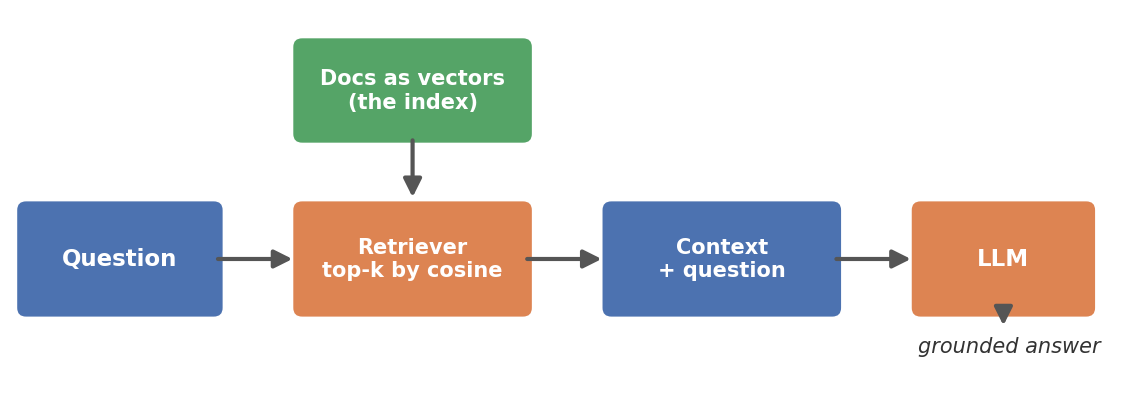


In [ ]:
# A minimal inline MockLLM — the same idea as the one in llm_providers.py (introduced in NB 17),
# vendored here so this notebook stays self-contained. (The retrieval side already has its own
# MockEmbedder defined above; the LLM side only needs a trivial QA responder, so we inline it.)
import json

class MockLLM:
    def chat(self, messages, **_):
        sys_msg = next((m["content"] for m in messages if m["role"] == "system"), "").lower()
        user_msgs = [m["content"] for m in messages if m["role"] == "user"]
        user_msg = user_msgs[-1] if user_msgs else ""
        if "answer the user's question" in sys_msg:
            # Extract a short answer based on context
            return {"text": "Answer based on the retrieved context: " +
                    user_msg.split("Question:")[-1].strip()[:120]}
        return {"text": "(mock answer)"}

llm = MockLLM()


def rag_answer(question: str, retriever=dense_retriever, k: int = 2):
    snippets = retriever(question, k=k)
    if not snippets:
        return None, []
    # Lookup the text for each retrieved name
    doc_text = {name: text for name, text in DOCS}
    context  = "\n\n".join(f"[{name}] {doc_text[name]}" for name, _ in snippets)

    system = ("You answer the user's question using ONLY the context provided. "
              "If the context does not contain the answer, say so clearly.")
    user   = f"Context:\n{context}\n\nQuestion: {question}"
    r = llm.chat(messages=[{"role": "system", "content": system},
                            {"role": "user",   "content": user}])
    return r["text"], snippets


answer, sources = rag_answer("How can I end my plan?", retriever=dense_retriever)
print(f"Answer : {answer}")
print(f"Sources: {[s[0] for s in sources]}")


> 🔌 **Using a real provider (OpenAI / Anthropic / Gemini / Ollama).**
> Every notebook in this module uses an offline `MockLLM` by default so you can run them without internet or API keys. Once you want real intelligence in the answers, swap one line — the unified interface in [`llm_providers.py`](../llm_providers.py) lets you use **OpenAI**, **Anthropic** (Claude), **Google** (Gemini), or a **local model via Ollama** without changing anything else.
> See the [LLM Providers Guide](./A1_llm_providers_guide.ipynb) for the swap-in instructions, model recommendations, and cost estimates.


## 🧪 Practice exercises

### Exercise 1 — ⭐ Add a doc and re-index

Add a new document about *"How to change my email address"* to `DOCS`, rebuild the TF-IDF and dense indexes, and verify that a query like `"update email"` returns it.

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
DOCS.append((
    "account.email",
    "To change your email address, go to Settings → Profile and enter the new "
    "address. We'll send a confirmation link to the new address; click it to "
    "complete the change."
))
NAMES = [n for n, _ in DOCS]
TEXTS = [t for _, t in DOCS]

# Rebuild indexes
doc_vectors = vectorizer.fit_transform(TEXTS)
doc_emb     = embedder.embed(TEXTS)

for name, score in dense_retriever("update email"):
    print(f"{score:.3f}  {name}")
```

**Pattern used.** Re-indexing is cheap for a small corpus; for a large production corpus you'd add only the new documents to a vector store rather than rebuild from scratch.
</details>

### Exercise 2 — ⭐⭐ Synonym test

Pick a document from the corpus, then craft three queries: one with **exact keywords**, one **paraphrased**, and one with **synonyms** (e.g. `"cancel"` → `"terminate"`). Compare the top-1 result from each retriever.

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
queries = [
    ("Exact   ", "I want to cancel my subscription"),
    ("Paraphr.", "How do I get out of my plan?"),
    ("Synonym ", "Please terminate my membership"),
]

print(f"{'kind':<10} {'kw':<25} {'tfidf':<25} {'dense':<25}")
for kind, q in queries:
    kw  = keyword_retriever(q, k=1)[0][0]
    tf  = tfidf_retriever(q,  k=1)[0][0]
    de  = dense_retriever(q,  k=1)[0][0]
    print(f"{kind:<10} {kw:<25} {tf:<25} {de:<25}")
```

What you should see: keyword nails the exact query, struggles on the paraphrase, drops on the synonym. Dense retrieval should keep up better — though with the mock embedder the effect is muted; a real sentence-transformer would nail all three.
</details>

### Exercise 3 — ⭐⭐ Add MRR to the dashboard

Build a function `compare_retrievers_table(retrievers, eval_set)` that returns a DataFrame with one row per retriever and columns `retrieval@1`, `retrieval@3`, `MRR`, sorted by MRR descending. Pretty-print the result.

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
def compare_retrievers_table(retrievers: dict, eval_set):
    rows = {name: evaluate(fn, eval_set) for name, fn in retrievers.items()}
    return pd.DataFrame(rows).T.sort_values("MRR", ascending=False).round(3)

compare_retrievers_table({"keyword": keyword_retriever,
                          "TF-IDF":  tfidf_retriever,
                          "dense":   dense_retriever}, EVAL)
```

**Why this matters.** The function is the small piece of code you keep around forever: every time you tweak a retriever, run this and see the regression in 0.1 seconds. That's the discipline production AI teams use.
</details>

### Exercise 4 — ⭐⭐ Debug me 🐞

The cell below tries to use the dense retriever on a brand-new document that's *not* yet in the index, and gets a wrong-looking score. Find the bug.

```python
new_doc_text = "We accept Visa, Mastercard, and PayPal at checkout."
sim = embedder.embed([new_doc_text])[0] @ doc_emb.T
print("Top match:", NAMES[np.argmax(sim)])
```

In [ ]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
# Your fixed version  👇


<details>
<summary>💡 <b>Solution</b></summary>

The bug isn't a code error — it's a *conceptual* one. The cell asks "which existing document is most similar to my new doc?" but the user probably meant "add my new doc and then retrieve". You can answer the comparison question, but you have to *interpret* what the score means.

```python
new_doc_text = "We accept Visa, Mastercard, and PayPal at checkout."   # the new doc from the exercise prompt
# Correct interpretation: the new doc is most similar to whichever existing doc shares the most semantic content.
sim = embedder.embed([new_doc_text])[0] @ doc_emb.T
order = np.argsort(-sim)
for idx in order[:3]:
    print(f"{sim[idx]:.3f}  {NAMES[idx]}")
```

The score itself isn't "wrong" — it's correctly showing that *no document in our corpus is about payment methods*, so the top match is weak. **Lesson.** Always look at the *similarity score*, not just the top-1 name. A confident retriever returns a top score around 0.6–0.9 for a relevant match; below 0.3 means "nothing here is relevant".
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise A — ⭐⭐⭐ Hybrid retriever — TF-IDF and dense combined

Build a `hybrid_retriever(query, k=3, alpha=0.5)` that combines TF-IDF and dense similarities as `alpha * tfidf_sim + (1 - alpha) * dense_sim`. Evaluate it on the existing EVAL set; compare to the individual retrievers.


<details>
<summary>💡 <b>Solution</b></summary>

```python
def hybrid_retriever(query, k=3, alpha=0.5):
    q_tfidf = vectorizer.transform([query])
    sims_tf = cosine_similarity(q_tfidf, doc_vectors)[0]
    sims_dn = doc_emb @ embedder.embed([query])[0]
    # Normalise each to [0,1] before combining (so alpha is meaningful)
    def norm(x):
        return (x - x.min()) / (x.max() - x.min() + 1e-9)
    sims = alpha * norm(sims_tf) + (1 - alpha) * norm(sims_dn)
    order = np.argsort(-sims)[:k]
    return [(NAMES[i], float(sims[i])) for i in order]


hybrid_eval = evaluate(hybrid_retriever, EVAL)
print("hybrid (α=0.5):", {k: round(v, 3) for k, v in hybrid_eval.items()})
```

**Hybrid usually wins** because the two retrievers fail on
*different* queries — keyword loses on paraphrase, dense loses
on exact-identifier search. Production systems combine them and
often *re-rank* the union with a smarter model on top.

</details>

### Stretch exercise B — ⭐⭐⭐ Visualise embeddings with PCA

Project the document embeddings into 2D using PCA and scatter-plot them, labelled by document name. Documents about similar topics should cluster together.


In [ ]:
# Your code here  👇
from sklearn.decomposition import PCA


<details>
<summary>💡 <b>Solution</b></summary>

```python
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
xy = pca.fit_transform(doc_emb)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(xy[:, 0], xy[:, 1], s=60, color="#4C72B0", edgecolor="black", alpha=0.8)
for (x, y), name in zip(xy, NAMES):
    ax.text(x + 0.02, y + 0.02, name, fontsize=9)
ax.set_title("Document embeddings projected to 2D (PCA)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()
```

**The 2D PCA plot is the embedding sanity check.** If documents
you *expect* to be similar appear close together, your embedder
is working. If they don't, no amount of retrieval tuning will
help — fix the embeddings first.

</details>

### Stretch exercise C — ⭐⭐⭐ Top-k retrieval with a confidence threshold

Modify the cosine-similarity retriever from the chapter so it returns the top-k results **only if they exceed a similarity floor**; if no candidate clears the floor, return an empty list (a common 'I don't know' signal).

Use the MockEmbedder from `llm_providers.py` so this runs offline.

In [ ]:
# Your code here  👇
# Make the repo-root llm_providers.py importable regardless of which folder
# Jupyter launched the kernel in (it lives at the course root).
import sys, pathlib
_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p / "llm_providers.py").exists()), None)
if _root:                       # local checkout — use the repo's module
    sys.path.insert(0, str(_root))
else:                           # Colab / standalone — fetch it next to the notebook
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/ChrisW09/Python-for-AI-Driven-Automation"
        "/main/llm_providers.py", "llm_providers.py")

from llm_providers import MockEmbedder
import numpy as np

KB = [
    ("refunds",  "Refunds are issued within 5 business days."),
    ("cancel",   "You can cancel your subscription from the Billing page."),
    ("reset",    "Reset your password from the Sign-in screen."),
    ("export",   "Data exports finish in under a minute."),
]
emb = MockEmbedder(seed=0)
doc_vecs = emb.embed([d for _, d in KB])

def retrieve(query, k=2, min_sim=0.2):
    ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from llm_providers import MockEmbedder
import numpy as np

KB = [
    ("refunds",  "Refunds are issued within 5 business days."),
    ("cancel",   "You can cancel your subscription from the Billing page."),
    ("reset",    "Reset your password from the Sign-in screen."),
    ("export",   "Data exports finish in under a minute."),
]
emb = MockEmbedder(seed=0)
doc_vecs = emb.embed([d for _, d in KB])

def retrieve(query, k=2, min_sim=0.2):
    q = emb.embed([query])[0]
    sims = doc_vecs @ q          # cosine sim because vectors are L2-normalised
    order = np.argsort(sims)[::-1]
    out = []
    for i in order[:k]:
        if sims[i] >= min_sim:
            out.append((KB[i][0], float(sims[i])))
    return out

print(retrieve("How do I get my money back?"))
print(retrieve("What's the weather in Paris?"))
```

**Reasoning.** Two production-grade habits this exercise builds. (1) When your embeddings are L2-normalised (`MockEmbedder` and most hosted embedders are), cosine similarity is the same as a dot product — much faster, no division. (2) **The threshold is your 'I don't know' switch.** Without it, every query — even 'weather in Paris' — gets a confident-looking top-k. With it, you can fall back to a graceful 'I don't have an answer in my knowledge base.' Tuning `min_sim` is part of the RAG design — too high and you reject good answers, too low and you hallucinate. Calibrate it on a small labelled set.
</details>

### Stretch exercise D — ⭐⭐⭐ Hybrid retrieval: keyword + embedding

Combine two signals: a **keyword overlap score** (intersection / union of lowercase word sets) and the **embedding cosine similarity**. The hybrid score is a weighted blend `hybrid = α · keyword + (1 − α) · cosine`. Return the top-1 document under each strategy and comment on which one performs better on the query *'cancel my subscription please'*.

In [ ]:
# Your code here  👇
from llm_providers import MockEmbedder
import numpy as np
import re

KB = [
    ("refunds",  "Refunds are issued within 5 business days."),
    ("cancel",   "You can cancel your subscription from the Billing page."),
    ("reset",    "Reset your password from the Sign-in screen."),
    ("export",   "Data exports finish in under a minute."),
]
emb = MockEmbedder(seed=0)
doc_vecs = emb.embed([d for _, d in KB])

def tok(s): return set(re.findall(r"[a-z]+", s.lower()))
doc_toks = [tok(d) for _, d in KB]

def hybrid_top1(query, alpha=0.5):
    ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from llm_providers import MockEmbedder
import numpy as np
import re

KB = [
    ("refunds",  "Refunds are issued within 5 business days."),
    ("cancel",   "You can cancel your subscription from the Billing page."),
    ("reset",    "Reset your password from the Sign-in screen."),
    ("export",   "Data exports finish in under a minute."),
]
emb = MockEmbedder(seed=0)
doc_vecs = emb.embed([d for _, d in KB])

def tok(s): return set(re.findall(r"[a-z]+", s.lower()))
doc_toks = [tok(d) for _, d in KB]

def hybrid_top1(query, alpha=0.5):
    q_vec = emb.embed([query])[0]
    q_toks = tok(query)
    cosines = doc_vecs @ q_vec
    jaccards = [
        len(q_toks & dt) / max(1, len(q_toks | dt))
        for dt in doc_toks
    ]
    hybrid = alpha * np.array(jaccards) + (1 - alpha) * cosines
    return KB[int(np.argmax(hybrid))][0], dict(
        keyword=KB[int(np.argmax(jaccards))][0],
        embedding=KB[int(np.argmax(cosines))][0],
    )

best, details = hybrid_top1("cancel my subscription please", alpha=0.5)
print("hybrid pick:", best)
print("single-signal picks:", details)
```

**Reasoning.** Keyword and embedding signals fail on opposite problems: keyword search misses *'cancel' vs 'unsubscribe'* (semantic match), embeddings sometimes miss exact identifier matches like product codes or part numbers (lexical match). A simple weighted blend recovers most of both — production systems like Elasticsearch's hybrid retriever, OpenSearch, and Vespa all do some version of this. Tune `alpha` on labelled examples; in practice 0.3–0.5 is a common range. If you want to go further, look up **BM25** as a better keyword signal than Jaccard.
</details>

## 🎁 Bonus mini-project — Add a confidence threshold

Modify `rag_answer` so that if the top similarity score is below 0.3, it returns the polite string `"I don't have enough information about that. Please contact a human agent."` instead of calling the LLM. This is the production safety pattern — **fail explicitly when retrieval is weak**, rather than hallucinate.

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
def rag_answer_safe(question, retriever=dense_retriever, k=2, threshold=0.3):
    snippets = retriever(question, k=k)
    if not snippets or snippets[0][1] < threshold:
        return "I don't have enough information about that. Please contact a human agent.", []

    doc_text = {name: text for name, text in DOCS}
    context  = "\n\n".join(f"[{name}] {doc_text[name]}" for name, _ in snippets)
    system   = ("You answer the user's question using ONLY the context provided.")
    user     = f"Context:\n{context}\n\nQuestion: {question}"
    r = llm.chat(messages=[{"role": "system", "content": system},
                            {"role": "user",   "content": user}])
    return r["text"], snippets


# In-corpus question → real answer
print(rag_answer_safe("How can I end my plan?")[0])
# Out-of-corpus question → graceful refusal
print(rag_answer_safe("What's the capital of Iceland?")[0])
```

**Why this matters.** A retriever with low confidence almost always means *the user asked about something not in your knowledge base*. Most AI failures come from confidently answering off-topic questions. A confidence threshold is the single most important production guardrail you can add.
</details>

## 🧠 Key takeaways

1. **Keyword overlap fails on paraphrasing**; TF-IDF helps; dense embeddings handle synonyms and rewording.
2. An embedding is a **vector** placed such that **semantic similarity → cosine similarity**.
3. **TF-IDF is a strong, free, offline baseline.** Don't skip past it on the way to dense embeddings.
4. Dense embeddings come in two flavours: **hosted APIs** (OpenAI, Cohere) and **local models** (sentence-transformers). The retrieval code is identical.
5. **Always evaluate retrievers** with `retrieval@k` and MRR on a small labelled set.
6. **Hybrid search** (lexical + dense) is the current production state of the art.
7. **Confidence thresholds** are the single most important RAG safety guardrail — refuse to answer when the top match is weak.
8. The vector database in your production system is just a **fast version of the dot-product loop you wrote here**.

## ✅ Self-assessment

- [ ] Explain what an embedding is and why cosine similarity works
- [ ] Build a TF-IDF retriever in scikit-learn
- [ ] Plug in (or mock) a dense embedder and retrieve by semantic similarity
- [ ] Compute retrieval@1, retrieval@3, MRR on a small eval set
- [ ] Compare retrievers head-to-head and decide which to ship
- [ ] Add a confidence threshold to refuse weak retrievals

## 🚀 Next step

Continue with **Notebook 24 — Tool Calling and Small Agents**, where the LLM stops just *answering questions* and starts *taking actions* — running your functions, doing math, querying your data — on its own.